In [552]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [1508]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
ticker = 'META'
df = yf.download(ticker, '2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [1543]:
df

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2020-01-02,296.888184,296.906479,294.749737,295.672752,59151200
2020-01-03,294.640045,295.764112,293.442881,293.497711,77709700
2020-01-06,295.764130,295.846374,292.766617,292.885424,55653900
2020-01-07,294.932556,295.672787,294.484742,295.197558,40496400
2020-01-08,296.504395,297.719826,294.877711,295.124445,68296000
...,...,...,...,...,...
2026-06-01,758.539978,760.280029,754.690002,755.359985,43634900
2026-06-02,759.570007,760.400024,756.750000,757.030029,31581900


<Axes: xlabel='Date'>

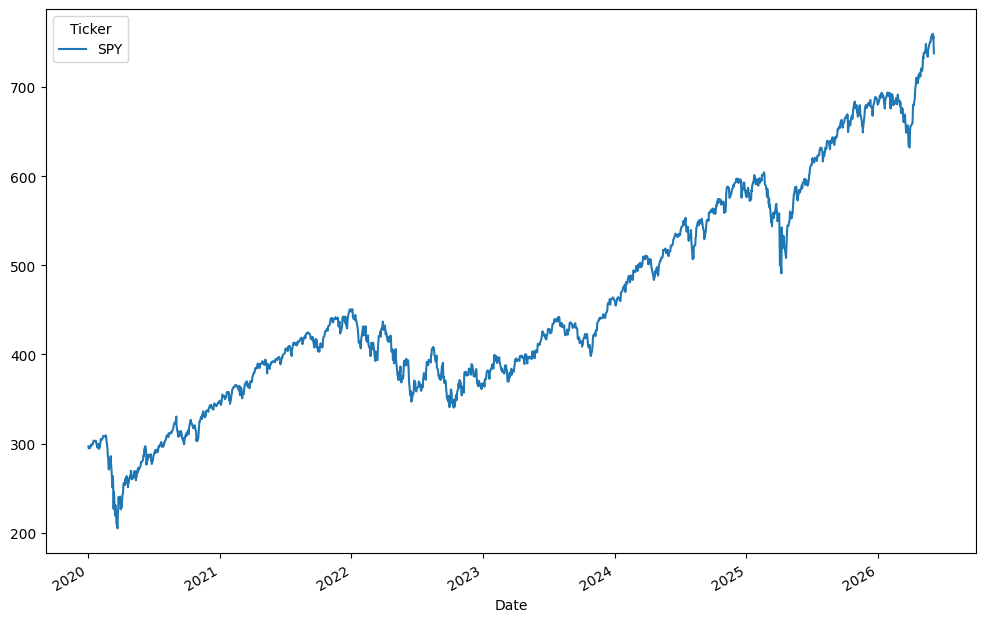

In [1544]:
df.Close.plot(figsize=(12, 8))

In [1545]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])

In [1546]:
df.Close

Ticker,SPY
Date,
2020-01-02,-1.297710
2020-01-03,-1.315970
2020-01-06,-1.306840
2020-01-07,-1.313594
2020-01-08,-1.300827
...,...
2026-06-01,2.451880
2026-06-02,2.460246
2026-06-03,2.416955


In [1547]:
# Creating the data here (Sliding window = 30)
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [1548]:
data

array([[[-1.29770998],
        [-1.31596962],
        [-1.30683967],
        ...,
        [-1.22059001],
        [-1.20455696],
        [-1.20722922]],

       [[-1.31596962],
        [-1.30683967],
        [-1.31359381],
        ...,
        [-1.20455696],
        [-1.20722922],
        [-1.20322071]],

       [[-1.30683967],
        [-1.31359381],
        [-1.30082716],
        ...,
        [-1.20722922],
        [-1.20322071],
        [-1.20967889]],

       ...,

       [[ 2.00954993],
        [ 2.06746066],
        [ 2.04504354],
        ...,
        [ 2.43514859],
        [ 2.45188013],
        [ 2.46024615]],

       [[ 2.06746066],
        [ 2.04504354],
        [ 2.08963389],
        ...,
        [ 2.45188013],
        [ 2.46024615],
        [ 2.41695512]],

       [[ 2.04504354],
        [ 2.08963389],
        [ 2.09962393],
        ...,
        [ 2.46024615],
        [ 2.41695512],
        [ 2.44010345]]], shape=(1585, 30, 1))

In [1549]:
train_size = int(0.8 * len(data)) # Use 80% of the data for training, the other 20% for testing

# This is the 80% of the data for TRAINING
x_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device) # From the start to the 80% mark, everything BUT the last value of each 30 set
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device) # From the start to the 80% mark, ONLY the last value of each 30 set

# This is the 20% of the data for TESTING
x_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device) # From the 80% mark to the end, everything BUT the last value of each 30 set
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device) # From the 80% mark to the end, ONLY the last value of each 30 set

In [1550]:
class PredictionModel(nn.Module): # nn.Module is a PyTorch neural network
    # input_dim = number of input features per time step
    # hidden_dim = size of the LSTM's memory/hidden representation at 29 days per sequence -> LSTM = RNN that can learn long-term dependencies
    # num_layers = number of stacked LSTM layers
    # output_dim = number of values you want to predict
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim # This is the model's memory size -> Giving the LSTM internal memory to learn from the data, which is crucial for time series prediction

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device) # Hidden state = Short-term memory
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device) # Cell state = Long-term memory (LSTM's unique feature)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [1551]:
# If input_dim=1 and output_dim=1 --> If you only want close price
# If input_dim=4 --> You probably looking for Close, Open, Volume, RSI
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.015) # Adam is an optimization algorithm that adjusts the learning rate for each parameter based on estimates of first and second moments of the gradients, which can lead to faster convergence compared to traditional methods like SGD.

In [1552]:
num_epochs = 400

for i in range(num_epochs):
    y_train_pred = model(x_train) # This secretly runs forward() internally

    loss = criterion(y_train_pred, y_train)

    # if i % 25 == 0:
    #     print(i, loss.item())

    optimizer.zero_grad() # Clear gradients from the previous step
    loss.backward() # Compute gradients based on the loss
    optimizer.step() # Update model parameters based on the computed gradients

    if i % 25 ==0:
        model.eval()
        with torch.no_grad():
            y_test_pred = model(x_test)
            test_loss = criterion(y_test_pred, y_test)
            print(
                f"Epoch {i},: "
                f"Train Loss: {loss.item():.6f}, "
                f"Test Loss: {test_loss.item():.6f}"
            )

Epoch 0,: Train Loss: 0.569235, Test Loss: 2.999941
Epoch 25,: Train Loss: 0.005580, Test Loss: 0.122710
Epoch 50,: Train Loss: 0.002224, Test Loss: 0.147016
Epoch 75,: Train Loss: 0.001962, Test Loss: 0.112345
Epoch 100,: Train Loss: 0.001856, Test Loss: 0.093607
Epoch 125,: Train Loss: 0.001762, Test Loss: 0.080124
Epoch 150,: Train Loss: 0.001681, Test Loss: 0.068872
Epoch 175,: Train Loss: 0.001611, Test Loss: 0.059502
Epoch 200,: Train Loss: 0.001555, Test Loss: 0.051579
Epoch 225,: Train Loss: 0.001510, Test Loss: 0.044979
Epoch 250,: Train Loss: 0.001474, Test Loss: 0.039611
Epoch 275,: Train Loss: 0.001447, Test Loss: 0.035371
Epoch 300,: Train Loss: 0.001425, Test Loss: 0.032163
Epoch 325,: Train Loss: 0.001407, Test Loss: 0.029892
Epoch 350,: Train Loss: 0.001392, Test Loss: 0.028464
Epoch 375,: Train Loss: 0.001379, Test Loss: 0.027778


In [1553]:
model.eval()

y_test_pred = model(x_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())

y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [1554]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [1555]:
train_rmse

4.556735992431641

In [1556]:
test_rmse

20.44960594177246

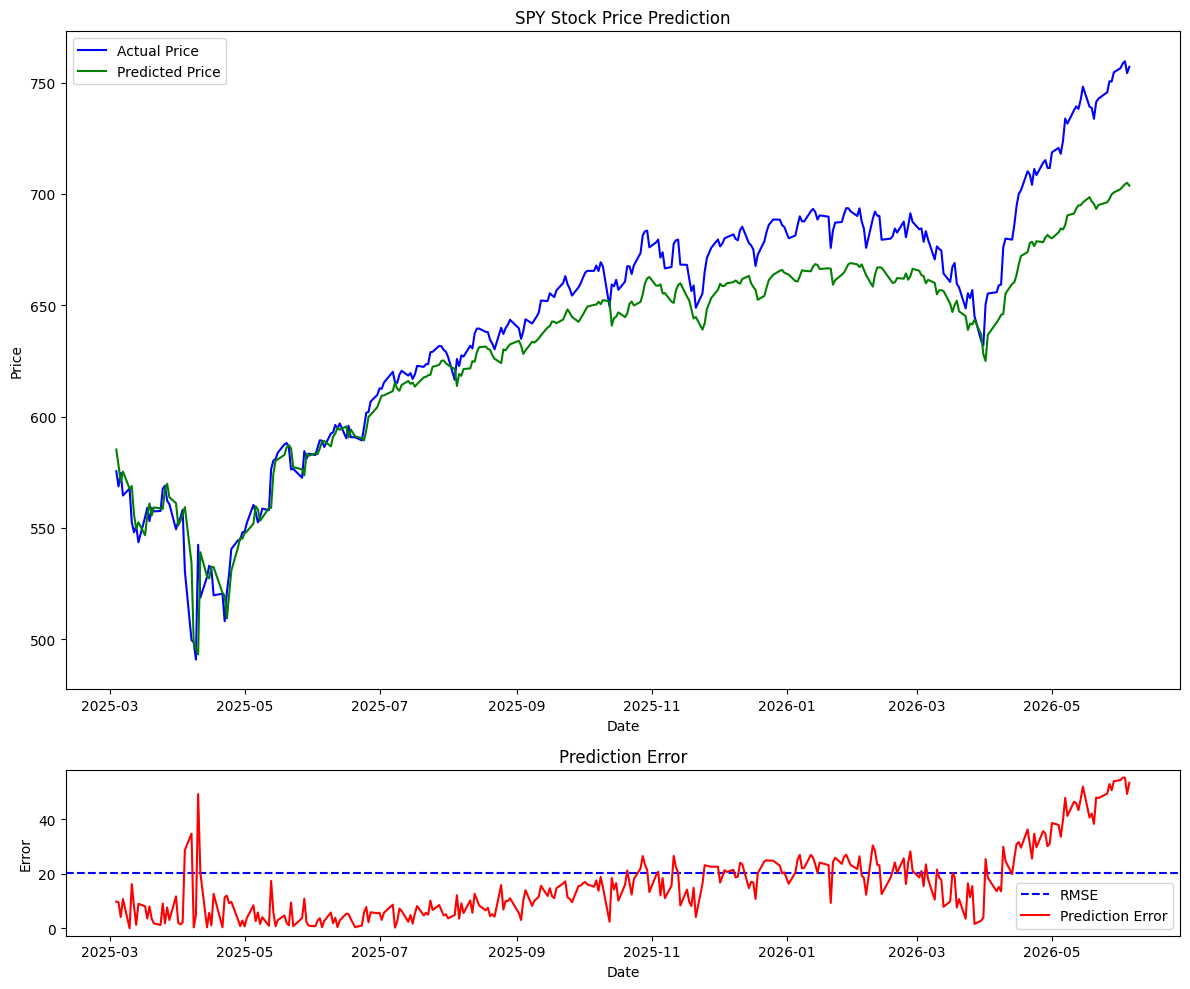

In [1557]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1) # 4 Rows 1 Column

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = 'blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()

plt.show()